
# Analysis of Urban Built-up Area in BWCA (2010, 2015, 2020) Using Google Earth Engine

## Data and Study Area
The Boundary Waters Canoe Area (BWCA) in northern Minnesota is a protected wilderness, so any **urban built-up area** within its boundaries should be minimal. We use **Landsat satellite imagery** to detect built-up surfaces for the years **2010**, **2015**, and **2020**. Specifically:  

- **2010:** Landsat 5 TM Surface Reflectance (Collection 2, Level 2).  
- **2015 & 2020:** Landsat 8 OLI Surface Reflectance (Collection 2, Level 2).  

Each year’s data is limited to **April–September** (spring/summer months) when there’s no snow cover and good visibility. We filter images to those with **< 10% cloud cover** (using the `CLOUD_COVER` metadata). The BWCA region is defined by a geometry (approximate bounding box) covering the wilderness area in Minnesota.

## Methodology
To analyze built-up area, the following steps are performed for each year (2010, 2015, 2020):

1. **Image Collection Filtering:** Retrieve the Landsat ImageCollection for the year (Landsat 5 for 2010, Landsat 8 for 2015/2020). Filter by date (`April 1 – September 30`) and by `CLOUD_COVER < 10%`.  
2. **Cloud/Snow/Saturation Masking:** For each image, apply a mask using the QA (quality) bands. We use the `QA_PIXEL` bitmask to **mask out clouds and snow** (e.g. bit 3 = cloud, bit 5 = snow) ([USGS Landsat 5 Level 2, Collection 2, Tier 1  |  Earth Engine Data Catalog  |  Google for Developers](https://developers.google.com/earth-engine/datasets/catalog/LANDSAT_LT05_C02_T1_L2#:~:text=,Dilated%20Cloud%20bits%20are%20set)), and `QA_RADSAT` to mask out **saturated pixels** (pixels where any band is radiometrically saturated). This ensures only clear, valid pixels remain.  
3. **Apply Scale Factors:** Scale the Landsat Level-2 surface reflectance bands by the appropriate **scale factor (0.0000275)** and add the **offset (-0.2)** ([How do I use a scale factor with Landsat Level-2 science products? | U.S. Geological Survey](https://www.usgs.gov/faqs/how-do-i-use-a-scale-factor-landsat-level-2-science-products#:~:text=,0.2%20per%20pixel)) to convert digital numbers to reflectance. This is done for all reflective bands (blue, green, red, NIR, SWIR).  
4. **Median Composite:** After masking and scaling, combine all images in the year’s collection using a **median** reducer. This yields one representative image per year where each pixel is the median reflectance value over the April–Sept period (minimizing residual cloud effects).  
5. **Compute NDBI:** Calculate the **Normalized Difference Built-up Index (NDBI)** for the year’s composite. NDBI is defined as:  
   $$ \text{NDBI} = \frac{\text{SWIR} - \text{NIR}}{\text{SWIR} + \text{NIR}} $$  
   We use the appropriate bands for each sensor (for Landsat 5: SWIR1 = Band5 and NIR = Band4; for Landsat 8: SWIR1 = Band6 and NIR = Band5) ([(PDF) NDVI, NDBI & NDWI Calculation Using Landsat 7, 8](https://www.researchgate.net/publication/327971920_NDVI_NDBI_NDWI_Calculation_Using_Landsat_7_8#:~:text=For%20Landsat%207%20data%2C%20NDBI,Band)). This index highlights built-up (man-made) surfaces, which typically reflect more in SWIR than NIR, yielding **positive NDBI** values. Vegetation gives negative NDBI (higher NIR), and water is usually negative or near zero.  
6. **Built-up Mask (Threshold):** Create a binary mask of **built-up areas** by thresholding NDBI > 0. Pixels with NDBI > 0 are considered built-up (1), and others are non-built (0). This is a simple threshold that captures areas with SWIR reflectance exceeding NIR reflectance (indicative of urban or bare ground surfaces).  
7. **Area Calculation:** Multiply the built-up binary mask by the pixel area (30 m resolution → each pixel ≈900 m²) to get an image of built-up area (m²) per pixel. Then sum over the BWCA region to get **total built-up area** in square meters for that year. The code uses Earth Engine’s `ee.Image.pixelArea()` and `reduceRegion` to compute this sum. 
8. **Output Results:** Print out a table of **Year vs. Built-up Area (m²)**, and plot a simple chart of built-up area across the three years using matplotlib. This provides a quick visualization of any trend (increase or decrease) in built development inside the BWCA over time.




In [1]:
import ee
import pandas as pd
import censusdata
from datetime import datetime
import ee
import geemap
import matplotlib.pyplot as plt

# Initialize Earth Engine - authenticate if necessary
try:
    ee.Initialize()
except Exception as e:
    ee.Authenticate()  # Will prompt for authentication if not already authenticated
    ee.Initialize()

In [2]:
m = geemap.Map(center=[48.15, -91.25], zoom=10)
m.add_basemap('SATELLITE')
m.add_basemap('Esri.WorldStreetMap')
m.add_draw_control()      # click & draw your ROI
m    

Map(center=[48.15, -91.25], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataG…

In [3]:
# 1. Define the BWCA region
roi_feature = ee.Feature(m.draw_last_feature)
bwca = roi_feature.geometry()

In [4]:
# 2. Collection IDs
L5 = "LANDSAT/LT05/C02/T1_L2"   # 1984–2012 (TM SR: SR_B1–SR_B5, SR_B7)
L8 = "LANDSAT/LC08/C02/T1_L2"   # 2013–present (OLI SR: SR_B1–SR_B7)

# 3a. Mask & scale for Landsat 5
def mask_scale_L5(image):
    qa = image.select('QA_PIXEL')
    mask = (
        qa.bitwiseAnd(1<<0).eq(0)    # no fill
        .And(qa.bitwiseAnd(1<<1).eq(0))  # no dilated cloud
        .And(qa.bitwiseAnd(1<<3).eq(0))  # no cloud
        .And(qa.bitwiseAnd(1<<4).eq(0))  # no shadow
        .And(qa.bitwiseAnd(1<<5).eq(0))  # no snow
        .And(image.select('QA_RADSAT').eq(0))  # no saturation
    )
    img = image.updateMask(mask)
    sr_bands = ['SR_B1','SR_B2','SR_B3','SR_B4','SR_B5','SR_B7']
    scaled = img.select(sr_bands).multiply(0.0000275).add(-0.2)
    return img.addBands(scaled, overwrite=True)

# 3b. Mask & scale for Landsat 8
def mask_scale_L8(image):
    qa = image.select('QA_PIXEL')
    mask = (
        qa.bitwiseAnd(1<<0).eq(0)
        .And(qa.bitwiseAnd(1<<1).eq(0))
        .And(qa.bitwiseAnd(1<<3).eq(0))
        .And(qa.bitwiseAnd(1<<4).eq(0))
        .And(qa.bitwiseAnd(1<<5).eq(0))
        .And(image.select('QA_RADSAT').eq(0))
    )
    img = image.updateMask(mask)
    sr_bands = ['SR_B1','SR_B2','SR_B3','SR_B4','SR_B5','SR_B6','SR_B7']
    scaled = img.select(sr_bands).multiply(0.0000275).add(-0.2)
    return img.addBands(scaled, overwrite=True)

# Visualize false-color composites for 2010, 2015, 2020
for year in [2010, 2015, 2020]:
    coll_id = L5 if year < 2013 else L8
    mask_fn = mask_scale_L5 if year < 2013 else mask_scale_L8

    col = (ee.ImageCollection(coll_id)
           .filterDate(f'{year}-04-01', f'{year}-09-30')
           .filter(ee.Filter.lt('CLOUD_COVER', 20))
           .filterBounds(bwca)
           .map(mask_fn))

    med = col.median().clip(bwca)

    # SWIR2‑SWIR1‑Red for Landsat 5 / 8
    if year < 2013: # Landsat 5: NIR=SR_B4, SWIR1=SR_B5, Red=SR_B3
        bands = ['SR_B4','SR_B5','SR_B3']
    else: # Landsat 8: NIR=SR_B5, SWIR1=SR_B6, Red=SR_B4
        bands = ['SR_B5','SR_B6','SR_B4']

    fcc = med.select(bands)
    vis = {'min': 0, 'max': 0.4, 'gamma': 1.4}
    m.addLayer(fcc, vis, f'FCC {year}')

m.addLayerControl()

m  # display the map




Map(bottom=11660.0, center=[48.22467264956519, -91.58203125000001], controls=(WidgetControl(options=['position…

In [5]:
# ------------- 2.  Helper functions & IDs ------------------------------------
L5 = "LANDSAT/LT05/C02/T1_L2"          # 1984–2012
L8 = "LANDSAT/LC08/C02/T1_L2"          # 2013–present

def mask_scale_L5(image):
    qa = image.select('QA_PIXEL')
    mask = (qa.bitwiseAnd(1<<0).eq(0)
            .And(qa.bitwiseAnd(1<<1).eq(0))
            .And(qa.bitwiseAnd(1<<3).eq(0))
            .And(qa.bitwiseAnd(1<<4).eq(0))
            .And(qa.bitwiseAnd(1<<5).eq(0))
            .And(image.select('QA_RADSAT').eq(0)))
    img = image.updateMask(mask)
    sr_bands = ['SR_B1','SR_B2','SR_B3','SR_B4','SR_B5','SR_B7']
    scaled   = img.select(sr_bands).multiply(0.0000275).add(-0.2)
    return img.addBands(scaled, overwrite=True)

def mask_scale_L8(image):
    qa = image.select('QA_PIXEL')
    mask = (qa.bitwiseAnd(1<<0).eq(0)
            .And(qa.bitwiseAnd(1<<1).eq(0))
            .And(qa.bitwiseAnd(1<<3).eq(0))
            .And(qa.bitwiseAnd(1<<4).eq(0))
            .And(qa.bitwiseAnd(1<<5).eq(0))
            .And(image.select('QA_RADSAT').eq(0)))
    img = image.updateMask(mask)
    sr_bands = ['SR_B1','SR_B2','SR_B3','SR_B4','SR_B5','SR_B6','SR_B7']
    scaled   = img.select(sr_bands).multiply(0.0000275).add(-0.2)
    return img.addBands(scaled, overwrite=True)

# ------------- 3.  Build one composite per target year -----------------------
years = [2010, 2015, 2020]
images = []

for yr in years:
    coll_id = L5 if yr < 2013 else L8
    mask_fn = mask_scale_L5 if yr < 2013 else mask_scale_L8

    col = (ee.ImageCollection(coll_id)
           .filterDate(f'{yr}-04-01', f'{yr}-09-30')
           .filter(ee.Filter.lt('CLOUD_COVER', 20))
           .filterBounds(bwca)
           .map(mask_fn))

    med = col.median().clip(bwca)

    # Re‑map to common band names so we can use one vis dict for all years
    if yr < 2013:   # Landsat‑5
        med = med.select(['SR_B4','SR_B5','SR_B3'], ['NIR','SWIR1','RED'])
    else:           # Landsat‑8
        med = med.select(['SR_B5','SR_B6','SR_B4'], ['NIR','SWIR1','RED'])

    # stamp the image with its date so the slider shows it
    med = med.set('system:time_start', ee.Date.fromYMD(yr, 7, 1).millis())
    images.append(med)

# ------------- 4.  Create a collection from the list -------------------------
fcc_col = ee.ImageCollection.fromImages(images)

# ------------- 5.  Visualise --------------------------------------------------
vis   = {'min': 0, 'max': 0.4, 'gamma': 1.4, 'bands': ['SWIR1','NIR','RED']}
m.add_time_slider(fcc_col, vis_params=vis, layer_name="False‑color composites")

m.addLayerControl()
m


Map(bottom=11660.0, center=[48.22467264956519, -91.58203125000001], controls=(WidgetControl(options=['position…

Year	Built-up Area (m²)
2010	213550519
2015	153074514
2020	465886335


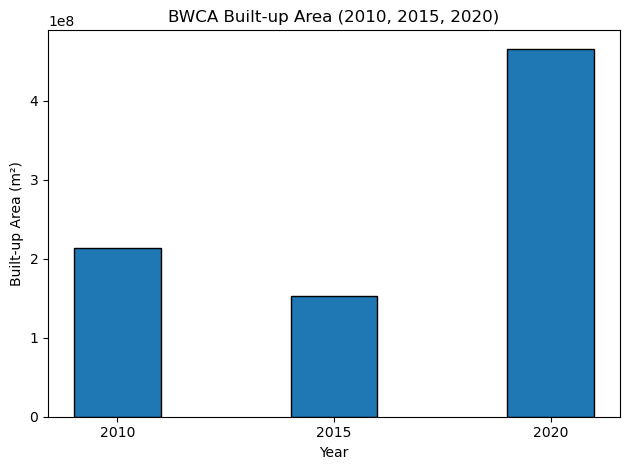

In [6]:
# 4. Process one year with refined recipe
def process_year(year):
    year = int(year)
    start = f"{year}-04-01"
    end   = f"{year}-09-30"  # exclusive → covers through Sept 30

    # Choose sensor and mask/scale function
    coll_id = L5 if year < 2013 else L8
    mask_scale = mask_scale_L5 if year < 2013 else mask_scale_L8

    # 4.1 Load, filter, mask/scale
    collection = (
        ee.ImageCollection(coll_id)
          .filterDate(start, end)
          .filter(ee.Filter.lt('CLOUD_COVER', 20))  # allow up to 20% clouds
          .filterBounds(bwca)
          .map(mask_scale)
    )

    # If no data, bail out
    if collection.size().getInfo() == 0:
        return year, 0

    # 4.2 Median composite for NDVI/NDWI
    med = collection.median()

    # Select bands per sensor
    if year < 2013:
        red, nir, swir = 'SR_B3','SR_B4','SR_B5'
    else:
        red, nir, swir = 'SR_B4','SR_B5','SR_B6'

    # Compute median NDVI & NDWI
    ndvi_med = med.normalizedDifference([nir, red]).rename('NDVI')
    ndwi_med = med.normalizedDifference([red, nir]).rename('NDWI')

    # 4.3 Max‐NDBI composite to capture strongest built signal
    def ndbi_img(img):
        return img.normalizedDifference([swir, nir]).rename('NDBI')
    max_ndbi = collection.map(ndbi_img).max().rename('maxNDBI')

    # 4.4 Build water/veg‐filtered built mask
    uv_mask = ndwi_med.lte(0).And(ndvi_med.lte(0.1))
    built_mask = max_ndbi.gt(0.1).And(uv_mask)

    # 4.5 Compute area
    area_img = ee.Image.pixelArea().updateMask(built_mask)
    area = area_img.reduceRegion(
        ee.Reducer.sum(),
        geometry=bwca,
        scale=30,
        maxPixels=1e8
    ).get('area').getInfo() or 0

    return year, int(area)

# 5. Run for 2010, 2015, 2020
results = [process_year(y) for y in [2010, 2015, 2020]]

# 6. Print & plot
print("Year\tBuilt-up Area (m²)")
for yr, a in results:
    print(f"{yr}\t{a}")

yrs, areas = zip(*results)
plt.bar(yrs, areas, width=2, edgecolor='black')
plt.xlabel('Year')
plt.ylabel('Built‑up Area (m²)')
plt.title('BWCA Built‑up Area (2010, 2015, 2020)')
plt.xticks(yrs)
plt.tight_layout()
plt.show()

In [61]:
def get_max_ndbi_watermasked(year):
    year = int(year)
    start, end = f"{year}-05-01", f"{year}-09-15"
    coll_id = "LANDSAT/LT05/C02/T1_L2" if year < 2013 else "LANDSAT/LC08/C02/T1_L2"
    mask_scale = mask_scale_L5 if year < 2013 else mask_scale_L8

    col = (ee.ImageCollection(coll_id)
           .filterDate(start, end)
           .filter(ee.Filter.lt('CLOUD_COVER', 30))
           .filterBounds(bwca)
           .map(mask_scale))

    if col.size().getInfo() == 0:
        return ee.Image(0).rename('maxNDBI')

    # 1. Build a median composite to derive NDWI
    med = col.median()
    if year < 2013:
        green, nir, swir = 'SR_B2','SR_B4','SR_B5'
    else:
        green, nir, swir = 'SR_B3','SR_B5','SR_B6'

    # Median NDWI: (GREEN - NIR)/(GREEN + NIR)
    ndwi_med = med.normalizedDifference([green, nir]).rename('NDWI')
    # Water mask: keep only NDWI <= 0 (non-water)
    water_mask = ndwi_med.lte(0)

    # 2. Compute per-image NDBI then take max
    def ndbi_img(img):
        return img.normalizedDifference([swir, nir]).rename('NDBI')

    max_ndbi = col.map(ndbi_img).max().rename('maxNDBI')

    # 3. Apply the water mask
    return max_ndbi.updateMask(water_mask).clip(bwca)


In [63]:
m = geemap.Map(center=[48.15, -91.25], zoom=10)
m.addLayer(bwca, {'color':'yellow'}, 'BWCA boundary')
m.add_basemap('SATELLITE')

vis = {'min': -0.2, 'max': 0.5, 'palette': ['white','lightgray','gray','orange','red']}
for yr in [2010, 2015, 2020]:
    layer = get_max_ndbi_watermasked(yr)
    m.addLayer(layer, vis, f"Max‑NDBI (water‑masked) {yr}")


m.addLayerControl()
m

Map(center=[48.15, -91.25], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataG…